In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

df = pd.read_csv('../data/creditcard.csv')

X = df.drop('Class', axis=1)
y = df['Class']

print("Ukuran X:", X.shape)
print("Ukuran y:", y.shape)

Ukuran X: (284807, 30)
Ukuran y: (284807,)


In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Data train:", X_train.shape)
print("Data test :", X_test.shape)
print("\nJumlah fraud di train:", y_train.sum())
print("Jumlah fraud di test :", y_test.sum())

Data train: (227845, 30)
Data test : (56962, 30)

Jumlah fraud di train: 394
Jumlah fraud di test : 98


In [3]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Rata-rata kolom Amount sebelum scaling:", X_train['Amount'].mean().round(2))
print("Rata-rata kolom Amount setelah scaling:", X_train_scaled[:, 29].mean().round(2))

Rata-rata kolom Amount sebelum scaling: 88.18
Rata-rata kolom Amount setelah scaling: 0.0


In [4]:
from collections import Counter

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("Jumlah transaksi SEBELUM SMOTE:")
print(Counter(y_train))

print("\nJumlah transaksi SETELAH SMOTE:")
print(Counter(y_train_smote))

Jumlah transaksi SEBELUM SMOTE:
Counter({0: 227451, 1: 394})

Jumlah transaksi SETELAH SMOTE:
Counter({0: 227451, 1: 227451})


In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import time

# ================================
# MODEL 1: Logistic Regression
# ================================
# Model paling sederhana — ini kita pakai sebagai "patokan awal"
# Ibarat kamu baru pertama kerja di bank, masih pakai cara manual
# untuk menilai transaksi mencurigakan
lr = LogisticRegression(max_iter=1000, random_state=42)

start = time.time()
lr.fit(X_train_smote, y_train_smote)
print(f"Logistic Regression selesai dilatih dalam {time.time()-start:.1f} detik")

# ================================
# MODEL 2: Random Forest
# ================================
# Model yang lebih canggih — dia bukan satu model, tapi kumpulan
# banyak model kecil yang voting bareng untuk memutuskan fraud atau tidak
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

start = time.time()
rf.fit(X_train_smote, y_train_smote)
print(f"Random Forest selesai dilatih dalam {time.time()-start:.1f} detik")

# ================================
# MODEL 3: XGBoost
# ================================
# Model paling canggih dari ketiganya — dia belajar dari kesalahan
# model sebelumnya secara bertahap sampai makin lama makin pintar
xgb = XGBClassifier(n_estimators=100, random_state=42, 
                     eval_metric='logloss', n_jobs=-1)

start = time.time()
xgb.fit(X_train_smote, y_train_smote)
print(f"XGBoost selesai dilatih dalam {time.time()-start:.1f} detik")

Logistic Regression selesai dilatih dalam 1.8 detik
Random Forest selesai dilatih dalam 71.3 detik
XGBoost selesai dilatih dalam 3.1 detik


In [6]:
# Kita minta ketiga model untuk menebak:
# "dari 56.962 transaksi ini, mana yang fraud?"
y_pred_lr  = lr.predict(X_test_scaled)
y_pred_rf  = rf.predict(X_test_scaled)
y_pred_xgb = xgb.predict(X_test_scaled)

# predict_proba = bukan cuma tebak fraud/tidak
# tapi juga kasih "tingkat keyakinan" 0% sampai 100%
# Contoh: "transaksi ini kemungkinan fraud 87%"
y_prob_lr  = lr.predict_proba(X_test_scaled)[:, 1]
y_prob_rf  = rf.predict_proba(X_test_scaled)[:, 1]
y_prob_xgb = xgb.predict_proba(X_test_scaled)[:, 1]

print("Ketiga model sudah selesai menebak!")
print(f"Jumlah transaksi yang dites: {len(y_test)}")
print(f"Jumlah fraud asli di data test: {y_test.sum()}")

Ketiga model sudah selesai menebak!
Jumlah transaksi yang dites: 56962
Jumlah fraud asli di data test: 98


In [7]:
def evaluasi_model(nama, y_asli, y_prediksi, y_probabilitas):
    print(f"\n{'='*45}")
    print(f"  HASIL MODEL: {nama}")
    print(f"{'='*45}")
    print(classification_report(y_asli, y_prediksi, 
                                  target_names=['Normal', 'Fraud']))
    auc = roc_auc_score(y_asli, y_probabilitas)
    print(f"AUC-ROC Score: {auc:.4f}")

evaluasi_model("Logistic Regression", y_test, y_pred_lr,  y_prob_lr)
evaluasi_model("Random Forest",       y_test, y_pred_rf,  y_prob_rf)
evaluasi_model("XGBoost",             y_test, y_pred_xgb, y_prob_xgb)


  HASIL MODEL: Logistic Regression
              precision    recall  f1-score   support

      Normal       1.00      0.97      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962

AUC-ROC Score: 0.9708

  HASIL MODEL: Random Forest
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.87      0.83      0.85        98

    accuracy                           1.00     56962
   macro avg       0.94      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962

AUC-ROC Score: 0.9685

  HASIL MODEL: XGBoost
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.73      0.85      0.78        98

    accuracy                           1.00     

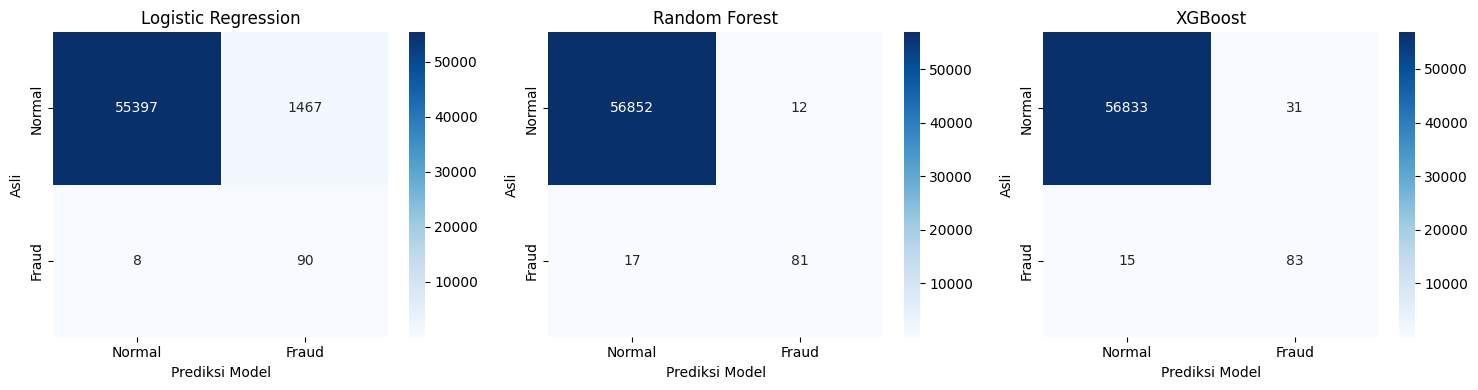

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
models   = ['Logistic Regression', 'Random Forest', 'XGBoost']
prediksi = [y_pred_lr, y_pred_rf, y_pred_xgb]

for ax, nama, pred in zip(axes, models, prediksi):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal','Fraud'],
                yticklabels=['Normal','Fraud'])
    ax.set_title(nama)
    ax.set_ylabel('Asli')
    ax.set_xlabel('Prediksi Model')

plt.tight_layout()
plt.show()

In [15]:
import os
import pickle

os.makedirs('../models', exist_ok=True)

# Simpan model dengan versi XGBoost yang baru
xgb.save_model('../models/xgboost_model.json')

with open('../models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Verifikasi — pastikan base_score sudah benar
import json
with open('../models/xgboost_model.json', 'r') as f:
    isi = json.load(f)

base_score = isi['learner']['learner_model_param']['base_score']
print(f"base_score: {base_score}")

if '[' in str(base_score):
    print("⚠️ Masih format lama, fixing...")
    isi['learner']['learner_model_param']['base_score'] = '0.5'
    with open('../models/xgboost_model.json', 'w') as f:
        json.dump(isi, f)
    print("✓ Fixed!")
else:
    print("✓ Format sudah benar!")

print("\nModel berhasil disimpan!")

base_score: [5E-1]
⚠️ Masih format lama, fixing...
✓ Fixed!

Model berhasil disimpan!


In [11]:
import os

print("Isi folder models:")
for file in os.listdir('../models'):
    print(f"  {file}")

Isi folder models:
  scaler.pkl
  xgboost_model.json


In [12]:
from xgboost import XGBClassifier

# Coba load ulang model yang sudah disimpan
test_model = XGBClassifier()
test_model.load_model('../models/xgboost_model.json')

# Coba buat SHAP explainer dari model yang di-load
import shap
test_explainer = shap.TreeExplainer(test_model)

print("✓ Model berhasil di-load!")
print("✓ SHAP explainer berhasil dibuat!")

C:\Users\Muhammad Fahri Hamdi\AppData\Roaming\Python\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ Model berhasil di-load!
✓ SHAP explainer berhasil dibuat!


In [14]:
import os
import json
from xgboost import XGBClassifier

# Latih ulang dengan base_score eksplisit
xgb_fix = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1,
    base_score=0.5
)

xgb_fix.fit(X_train_smote, y_train_smote)
print("✓ Model selesai dilatih ulang!")

# Simpan dulu ke json
xgb_fix.save_model('../models/xgboost_model.json')
print("✓ Model tersimpan!")

# ================================
# CEK ISI FILE JSON — ini yang penting!
# ================================
with open('../models/xgboost_model.json', 'r') as f:
    isi = json.load(f)

base_score = isi['learner']['learner_model_param']['base_score']
print(f"\nNilai base_score di dalam file: {base_score}")
print(f"Tipe datanya: {type(base_score)}")

if base_score == '[5E-1]' or '[' in str(base_score):
    print("\n⚠️ Masih format lama! Kita fix manual...")
    
    # Fix langsung di dalam file json
    isi['learner']['learner_model_param']['base_score'] = '0.5'
    
    with open('../models/xgboost_model.json', 'w') as f:
        json.dump(isi, f)
    
    print("✓ base_score sudah diperbaiki menjadi 0.5!")
else:
    print("\n✓ Format base_score sudah benar!")

# Verifikasi akhir
with open('../models/xgboost_model.json', 'r') as f:
    isi_cek = json.load(f)
print(f"\nVerifikasi akhir base_score: {isi_cek['learner']['learner_model_param']['base_score']}")

✓ Model selesai dilatih ulang!
✓ Model tersimpan!

Nilai base_score di dalam file: [5E-1]
Tipe datanya: <class 'str'>

⚠️ Masih format lama! Kita fix manual...
✓ base_score sudah diperbaiki menjadi 0.5!

Verifikasi akhir base_score: 0.5


In [16]:
import pickle
import os

os.makedirs('../models', exist_ok=True)

# Simpan pakai pickle — cara ini menyimpan SEMUA informasi model
# termasuk n_classes_ yang dibutuhkan predict_proba
with open('../models/xgboost_model_fix.pkl', 'wb') as f:
    pickle.dump(xgb, f)

with open('../models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("✓ Model tersimpan!")

# Test langsung di notebook
with open('../models/xgboost_model_fix.pkl', 'rb') as f:
    test_model = pickle.load(f)

import shap
test_explainer = shap.TreeExplainer(test_model)
print("✓ SHAP berhasil dibuat!")
print(f"✓ n_classes_: {test_model.n_classes_}")

✓ Model tersimpan!
✓ SHAP berhasil dibuat!
✓ n_classes_: 2


In [17]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# Hitung semua metrik untuk model XGBoost kita
accuracy  = accuracy_score(y_test, y_pred_xgb)
f1        = f1_score(y_test, y_pred_xgb)
auc_roc   = roc_auc_score(y_test, y_prob_xgb)

print("=== Performa Model XGBoost ===")
print(f"Accuracy  : {accuracy*100:.2f}%")
print(f"F1-Score  : {f1*100:.2f}%")
print(f"AUC-ROC   : {auc_roc*100:.2f}%")

=== Performa Model XGBoost ===
Accuracy  : 99.92%
F1-Score  : 78.30%
AUC-ROC   : 98.00%
